**Focus of the document**


This document focuses on the utilization of basic ML methods that are taught in the lecture of the course DSA210. The ML methods are somewhat considered to be basic due to nature of the dataset, and the course content.


Possible ideas;


- can daily entertainment behaviour signal about academic pressure
- Regression for the sequential data especially spotify is the best based on the EDA we have
- Predicting maybe whether a day has high activity after 21.30.
 




In [26]:
#----------------------IMPORTS-----------------------#

# Importing necessary libraries for data manipulation, visualization and machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

In [53]:
#----------------------DATASET PREPARATION-----------------------#
# Adding the combined daily dataset to the machine learning dataset.

project_root = Path.cwd()
if project_root.name == "MachineLearning":
    project_root = project_root.parent



# Defining paths of the files for easy reference and avoiding path issues in the folder structure.
youtube_path = project_root / "data_github/youtube_public/youtube_activity_public.csv"
spotify_path = project_root / "data_github/spotify_public/spotify_streaming_public.csv"
netflix_path = project_root / "data_github/netflix_public/netflix_viewing_public.csv"
prime_path = project_root / "data_github/prime_video_public/prime_video_watch_history_public.csv"
calendar_path = project_root / "data_github/academical_calendar/academicCalendar.jsonl"


# This is the path to store the results. It is in the MachineLearning/results
result_path = project_root / "MachineLearning/results"


In [28]:
#--------------LOADING THE DATASETS-----------------------#
youtube_data = pd.read_csv(youtube_path)
spotify_data = pd.read_csv(spotify_path)
netflix_data = pd.read_csv(netflix_path)
prime_data = pd.read_csv(prime_path)
calendar_data = pd.read_json(calendar_path, lines=True)

print("Loaded datasets:")
print("YouTube:", youtube_data.shape)
print("Spotify:", spotify_data.shape)
print("Netflix:", netflix_data.shape)
print("Prime Video:", prime_data.shape)
print("Academic calendar:", calendar_data.shape)

Loaded datasets:
YouTube: (34317, 16)
Spotify: (178202, 16)
Netflix: (2493, 11)
Prime Video: (719, 17)
Academic calendar: (15, 23)


In [29]:
#----------------------DATASET ADDING TIME STAMPS -----------------------#

# Having a common date that we would build the foundation of the ML. 

# For each of the data set making sure that we use a common date format and a common date column name. We will use "fine_date" as the common date column name.


for data in [youtube_data, spotify_data, netflix_data, prime_data]:
    data["fine_date"] = pd.to_datetime(data["fine_date"])



# YouTube and Spotify have exact timestamps, so they can be used for after-21:30 variables.
youtube_data["fine_time_start_dt"] = pd.to_datetime(
    youtube_data["fine_time_start"],
    errors="coerce",
    utc=True
).dt.tz_convert("Europe/Istanbul")

spotify_data["fine_time_start_dt"] = pd.to_datetime(
    spotify_data["fine_time_start"],
    errors="coerce",
    utc=True,
    format="mixed"
).dt.tz_convert("Europe/Istanbul")


# Spotify has different timestamps formats, I was getting 5404 rows rthat had invalid timestamps. I tried a different format to fix the issue. 
print("Invalid Spotify timestamps:", spotify_data["fine_time_start_dt"].isna().sum())


# Since we are interested in the late-evening / night activity, we will create a binary variable that indicates whether the activity started after 21:30 or not. This will be our target variable for the machine learning model.


# Building necessary columns for the future macxhine learning developments. Focusing on late evening night activities.
# After 21:30 until 04:59 is treated as late-evening / night activity.
youtube_data["is_after_2130"] = (
    (youtube_data["fine_time_start_dt"].dt.hour > 21) |
    (
        (youtube_data["fine_time_start_dt"].dt.hour == 21) &
        (youtube_data["fine_time_start_dt"].dt.minute >= 30)
    ) |
    (youtube_data["fine_time_start_dt"].dt.hour < 5)
)

# Same for Spotify.
spotify_data["is_after_2130"] = (
    (spotify_data["fine_time_start_dt"].dt.hour > 21) |
    (
        (spotify_data["fine_time_start_dt"].dt.hour == 21) &
        (spotify_data["fine_time_start_dt"].dt.minute >= 30)
    ) |
    (spotify_data["fine_time_start_dt"].dt.hour < 5)
)

#Checkcing before the ML so no errors in the timestamps.

print("Invalid YouTube timestamps:", youtube_data["fine_time_start_dt"].isna().sum())
print("Invalid Spotify timestamps:", spotify_data["fine_time_start_dt"].isna().sum())


Invalid Spotify timestamps: 0
Invalid YouTube timestamps: 0
Invalid Spotify timestamps: 0


In [30]:
#----------------------DATASET COMMON DATE RANGE-----------------------#

# Adding a common date range for all datasets to make sure that we are comparing the same time periods. We will create a new dataframe that contains all the dates in the common date range and then merge it with each of the datasets.
common_start_date = max(
    youtube_data["fine_date"].min(),
    spotify_data["fine_date"].min(),
    netflix_data["fine_date"].min(),
    prime_data["fine_date"].min()
)


# Adding a common end date as well, to make sure that we are comparing the same time periods. We will create a new dataframe that contains all the dates in the common date range and then merge it with each of the datasets.
common_end_date = min(
    youtube_data["fine_date"].max(),
    spotify_data["fine_date"].max(),
    netflix_data["fine_date"].max(),
    prime_data["fine_date"].max()
)

all_dates = pd.DataFrame({
    "fine_date": pd.date_range(common_start_date, common_end_date, freq="D")})



calendar_rows = []

#----------------------DATASET DATE CLASSES-----------------------#
# Assigning the classes based on the academic calendar.
# We will create a new dataframe that contains all the dates in the common date range and then merge it with each of the datasets. We will also create a new column that indicates whether the date is in the ordinary term, final exam period or summer work period.
for _, row in calendar_data.iterrows():
    term_start = pd.to_datetime(row["term_start_date"])
    final_start = pd.to_datetime(row["final_exam_start_date"])
    final_end = pd.to_datetime(row["final_exam_end_date"])

    for date_value in pd.date_range(term_start, final_end, freq="D"):
        if final_start <= date_value <= final_end:
            academic_period = "final_exam"
        else:
            academic_period = "ordinary_term"

        if row["term"] == "summer":
            analysis_period = "summer_work_period"
        else:
            analysis_period = academic_period

        calendar_rows.append({
            "fine_date": date_value,
            "academic_year": row["academic_year"],
            "term": row["term"],
            "academic_period": academic_period,
            "analysis_period": analysis_period,
            "is_final_exam_period": academic_period == "final_exam",
            "is_ordinary_term_day": academic_period == "ordinary_term"})

calendar_daily = pd.DataFrame(calendar_rows).drop_duplicates("fine_date", keep="first")

print("Common date range:")
print(common_start_date, "to", common_end_date)
print("Number of dates:", len(all_dates))


Common date range:
2022-04-17 00:00:00 to 2026-03-10 00:00:00
Number of dates: 1424


In [31]:
#----------------------YOUTUBE DAILY VARIABLES-----------------------#


# Creating daily aggregates for YouTube data. We will create the following daily variables:
# - youtube_daily_total_count: Total number of YouTube activities per day.
# - youtube_daily_watched_count: Total number of YouTube "Watched" activities per day.
# - youtube_daily_search_count: Total number of YouTube "Searched for" activities per day.
# - youtube_after_2130_count: Total number of YouTube activities that started after 21:30 per day.
# - youtube_after_2130_watched_count: Total number of YouTube "Watched" activities that started after 21:30 per day.


youtube_daily_total = (
    youtube_data
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_total_count"))

youtube_daily_watched = (
    youtube_data[youtube_data["action"] == "Watched"]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_watched_count"))

youtube_daily_search = (
    youtube_data[youtube_data["action"] == "Searched for"]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_search_count")
)

youtube_after_2130 = (
    youtube_data[youtube_data["is_after_2130"]]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_after_2130_count")
)

youtube_after_2130_watched = (
    youtube_data[
        youtube_data["is_after_2130"] &
        (youtube_data["action"] == "Watched")
    ]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_after_2130_watched_count")
)

youtube_daily = (
    all_dates
    .merge(youtube_daily_total, on="fine_date", how="left")
    .merge(youtube_daily_watched, on="fine_date", how="left")
    .merge(youtube_daily_search, on="fine_date", how="left")
    .merge(youtube_after_2130, on="fine_date", how="left")
    .merge(youtube_after_2130_watched, on="fine_date", how="left")
)

for column in youtube_daily.columns:
    if column != "fine_date":
        youtube_daily[column] = youtube_daily[column].fillna(0).astype(int)

print("YouTube daily sample:")
print(youtube_daily.sample(5))
print(youtube_daily.head())


YouTube daily sample:
     fine_date  youtube_daily_total_count  youtube_daily_watched_count  \
635 2024-01-12                          8                            7   
925 2024-10-28                          4                            2   
112 2022-08-07                          0                            0   
837 2024-08-01                          0                            0   
946 2024-11-18                          1                            1   

     youtube_daily_search_count  youtube_after_2130_count  \
635                           1                         0   
925                           2                         0   
112                           0                         0   
837                           0                         0   
946                           0                         0   

     youtube_after_2130_watched_count  
635                                 0  
925                                 0  
112                                 0  
837   

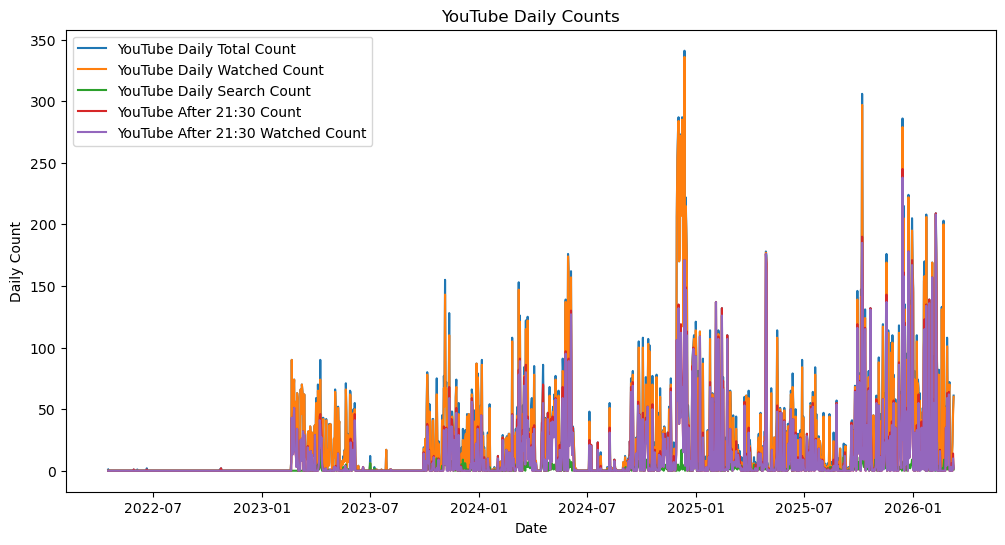

In [32]:
#------------- PLOT CHECK ------------
# Plotting the youtube daily counts to make sure the dataset uploaded correctly.
plt.figure(figsize=(12, 6))
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_total_count"], label="YouTube Daily Total Count")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_watched_count"], label="YouTube Daily Watched Count")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_search_count"], label="YouTube Daily Search Count")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_after_2130_count"], label="YouTube After 21:30 Count")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_after_2130_watched_count"], label="YouTube After 21:30 Watched Count")
plt.xlabel("Date")
plt.ylabel("Daily Count")
plt.title("YouTube Daily Counts")
plt.legend()
plt.show()

In [33]:
#----------------------NETFLIX AND PRIME VIDEO DAILY VARIABLES-----------------------#


# Creating daily aggregates for Netflix and Prime Video data. We will create the following daily variables:
# - netflix_daily_count: Total number of Netflix activities per day.
# - prime_video_daily_count: Total number of Prime Video activities per day.


netflix_daily = (
    netflix_data
    .groupby("fine_date")
    .size()
    .reset_index(name="netflix_daily_count")
)

prime_daily = (
    prime_data
    .groupby("fine_date")
    .size()
    .reset_index(name="prime_video_daily_count")
)

netflix_daily = all_dates.merge(netflix_daily, on="fine_date", how="left")
prime_daily = all_dates.merge(prime_daily, on="fine_date", how="left")

netflix_daily["netflix_daily_count"] = netflix_daily["netflix_daily_count"].fillna(0).astype(int)
prime_daily["prime_video_daily_count"] = prime_daily["prime_video_daily_count"].fillna(0).astype(int)

print("Netflix daily sample:")
print(netflix_daily.head())
print(netflix_daily.sample(5))
print()
print("Prime Video daily sample:")
print(prime_daily.head())
print(prime_daily.sample(5))



Netflix daily sample:
   fine_date  netflix_daily_count
0 2022-04-17                    0
1 2022-04-18                    0
2 2022-04-19                    0
3 2022-04-20                    1
4 2022-04-21                    0
      fine_date  netflix_daily_count
660  2024-02-06                    0
1229 2025-08-28                    0
671  2024-02-17                    0
668  2024-02-14                    0
1327 2025-12-04                    0

Prime Video daily sample:
   fine_date  prime_video_daily_count
0 2022-04-17                        0
1 2022-04-18                        0
2 2022-04-19                        0
3 2022-04-20                        0
4 2022-04-21                        0
      fine_date  prime_video_daily_count
933  2024-11-05                        0
1245 2025-09-13                        0
360  2023-04-12                        0
880  2024-09-13                        0
727  2024-04-13                        0


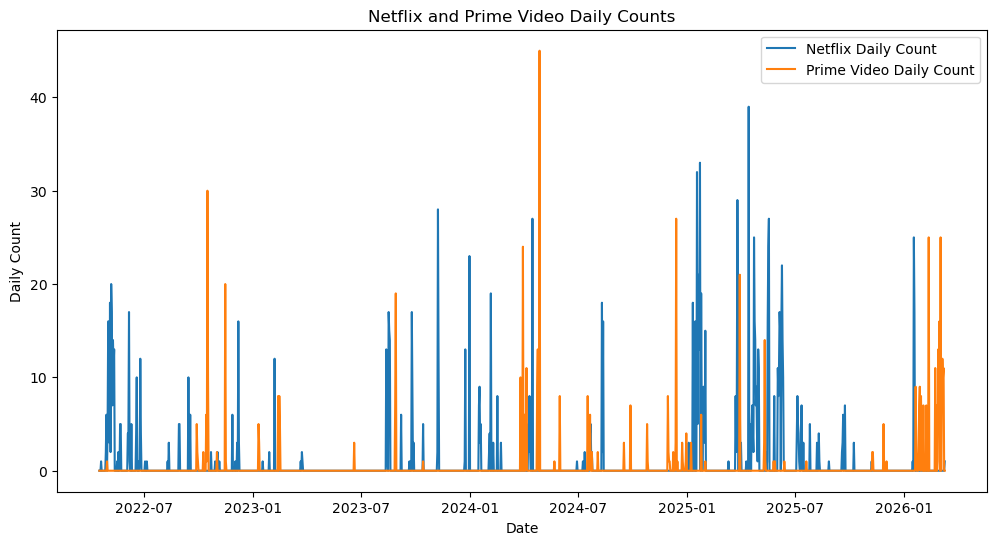

In [34]:
#------------PLOT CHECK--------------
# plotting the netflix and prime video daily counts to see if the data has been uploaded correctly.
plt.figure(figsize=(12, 6))
plt.plot(netflix_daily["fine_date"], netflix_daily["netflix_daily_count"], label="Netflix Daily Count")
plt.plot(prime_daily["fine_date"], prime_daily["prime_video_daily_count"], label="Prime Video Daily Count")
plt.xlabel("Date")
plt.ylabel("Daily Count")
plt.title("Netflix and Prime Video Daily Counts")
plt.legend()
plt.show()

In [35]:
#----------------------SPOTIFY DAILY VARIABLES-----------------------#

# Creating daily aggregates for Spotify data. We will create the following daily variables:
# - spotify_daily_hours: Total hours played on Spotify per day.
# - spotify_daily_stream_count: Total number of Spotify streams per day.
# - spotify_daily_unique_tracks: Total number of unique tracks played on Spotify per day.
# - spotify_after_2130_hours: Total hours played on Spotify that started after 21:30 per day.
# - spotify_after_2130_stream_count: Total number of Spotify streams that started after 21:30 per day.

spotify_daily = (
    spotify_data
    .groupby("fine_date")
    .agg(
        spotify_daily_hours=("hours_played", "sum"),
        spotify_daily_stream_count=("fine_record_id", "count"),
        spotify_daily_unique_tracks=("track_ref_id", "nunique")
    )
    .reset_index()
)

spotify_after_2130 = (
    spotify_data[spotify_data["is_after_2130"]]
    .groupby("fine_date")
    .agg(
        spotify_after_2130_hours=("hours_played", "sum"),
        spotify_after_2130_stream_count=("fine_record_id", "count")
    )
    .reset_index()
)

spotify_daily = (
    all_dates
    .merge(spotify_daily, on="fine_date", how="left")
    .merge(spotify_after_2130, on="fine_date", how="left")
)

spotify_daily["spotify_daily_hours"] = spotify_daily["spotify_daily_hours"].fillna(0)
spotify_daily["spotify_daily_stream_count"] = spotify_daily["spotify_daily_stream_count"].fillna(0).astype(int)
spotify_daily["spotify_daily_unique_tracks"] = spotify_daily["spotify_daily_unique_tracks"].fillna(0).astype(int)
spotify_daily["spotify_after_2130_hours"] = spotify_daily["spotify_after_2130_hours"].fillna(0)
spotify_daily["spotify_after_2130_stream_count"] = spotify_daily["spotify_after_2130_stream_count"].fillna(0).astype(int)

print("Spotify daily sample:")
print(spotify_daily.head())
print(spotify_daily.sample(5))



Spotify daily sample:
   fine_date  spotify_daily_hours  spotify_daily_stream_count  \
0 2022-04-17             1.603053                          70   
1 2022-04-18             0.385654                          11   
2 2022-04-19             0.002694                           7   
3 2022-04-20             0.905688                         135   
4 2022-04-21             0.634982                          64   

   spotify_daily_unique_tracks  spotify_after_2130_hours  \
0                           63                  0.117174   
1                            9                  0.264308   
2                            2                  0.000000   
3                          103                  0.905688   
4                           49                  0.268858   

   spotify_after_2130_stream_count  
0                               25  
1                               10  
2                                1  
3                              135  
4                               28  
    

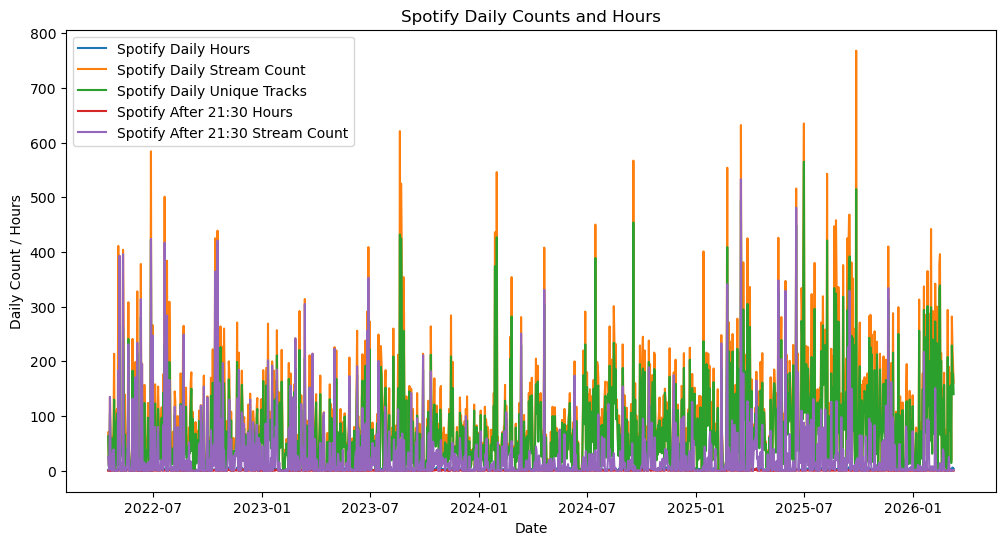

In [36]:
#------------- PLOT CHECK ------------
# Plotting the spotify daily counts to make sure the dataset uploaded correctly.
plt.figure(figsize=(12, 6))
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_daily_hours"], label="Spotify Daily Hours")
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_daily_stream_count"], label="Spotify Daily Stream Count")
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_daily_unique_tracks"], label="Spotify Daily Unique Tracks")
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_after_2130_hours"], label="Spotify After 21:30 Hours")
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_after_2130_stream_count"], label="Spotify After 21:30 Stream Count")
plt.xlabel("Date")
plt.ylabel("Daily Count / Hours")
plt.title("Spotify Daily Counts and Hours")
plt.legend()
plt.show()

In [37]:
#----------------------COMBINED DAILY PANEL-----------------------#


# Having a combined daily panel that contains all the daily variables from YouTube, Spotify, Netflix, Prime Video and the academic calendar. We will merge all the daily datasets on the "fine_date" column and then fill the missing values with 0 for the entertainment variables and with "outside_calendar" for the academic calendar variables. We will also create some additional variables that indicate whether the day is an active day for each platform and the total entertainment event count for each day.
combined_daily = (
    all_dates
    .merge(youtube_daily, on="fine_date", how="left")
    .merge(spotify_daily, on="fine_date", how="left")
    .merge(netflix_daily, on="fine_date", how="left")
    .merge(prime_daily, on="fine_date", how="left")
    .merge(calendar_daily, on="fine_date", how="left")
)


# Filling the missing values with 0 for the entertainment variables and with "outside_calendar" for the academic calendar variables.
# To make sure having a dataset that is corretly labeled troughout.
combined_daily["academic_year"] = combined_daily["academic_year"].fillna("outside_calendar")
combined_daily["term"] = combined_daily["term"].fillna("outside_calendar")
combined_daily["academic_period"] = combined_daily["academic_period"].fillna("outside_calendar")
combined_daily["analysis_period"] = combined_daily["analysis_period"].fillna("outside_calendar")

# Adding another column where we have a boolean value for whether the day is in the final exam period or not. This will be our target variable for the machine learning model.
for column in ["is_final_exam_period", "is_ordinary_term_day"]:
    combined_daily[column] = (
        combined_daily[column]
        .where(combined_daily[column].notna(), False)
        .astype(bool)
    )


#  Combining netlifx and prime daily counts to have a better
# datast that would be easier to work with in the ML models.
combined_daily["netflix_prime_daily_count"] = (
    combined_daily["netflix_daily_count"] +
    combined_daily["prime_video_daily_count"]
)


# Adding the daily days where the user was active on that platform by constrainting it with
# having an activity more than 0 for tthat day and platform.
combined_daily["youtube_active_day"] = combined_daily["youtube_daily_total_count"] > 0
combined_daily["spotify_active_day"] = combined_daily["spotify_daily_stream_count"] > 0
combined_daily["netflix_active_day"] = combined_daily["netflix_daily_count"] > 0
combined_daily["prime_video_active_day"] = combined_daily["prime_video_daily_count"] > 0
combined_daily["netflix_prime_active_day"] = combined_daily["netflix_prime_daily_count"] > 0


# Summing up the daily active platforms to have another variable that indicated
# jow many platforms the user used on specific day.
# This will give us an idea about the diversity of the user's entertainment activity on each day, which could be an important signal for the machine learning model.
combined_daily["daily_distinct_entertainment_platform_count"] = (
    combined_daily[[
        "youtube_active_day",
        "spotify_active_day",
        "netflix_active_day",
        "prime_video_active_day"
    ]]
    .sum(axis=1)
    .astype(int)
)


# Adding a variable that sums up the total entertainment event count for each day by summing up the daily counts of YouTube, Spotify, Netflix and Prime Video. This will give us an overall measure of the user's entertainment activity for each day.
combined_daily["total_entertainment_event_count"] = (
    combined_daily["youtube_daily_total_count"] +
    combined_daily["spotify_daily_stream_count"] +
    combined_daily["netflix_prime_daily_count"]
)

# Adding the share of the late-evening / night activity for YouTube and Spotify by dividing the after-21:30 counts by the total daily counts for each platform.
# This will give us a measure of how much of the user's entertainment activity is happening in the late-evening / night period, 
# which could be an important signal for the machine learning model.
combined_daily["youtube_after_2130_share"] = (
    combined_daily["youtube_after_2130_count"] /
    combined_daily["youtube_daily_total_count"].replace(0, np.nan)
).fillna(0)

combined_daily["spotify_after_2130_hour_share"] = (
    combined_daily["spotify_after_2130_hours"] /
    combined_daily["spotify_daily_hours"].replace(0, np.nan)
).fillna(0)

print("Combined daily shape:")
print(combined_daily.shape)
print()
print("Combined daily sample:")
print(combined_daily.head())
print(combined_daily.sample(5))

Combined daily shape:
(1424, 29)

Combined daily sample:
   fine_date  youtube_daily_total_count  youtube_daily_watched_count  \
0 2022-04-17                          1                            0   
1 2022-04-18                          0                            0   
2 2022-04-19                          0                            0   
3 2022-04-20                          0                            0   
4 2022-04-21                          0                            0   

   youtube_daily_search_count  youtube_after_2130_count  \
0                           0                         0   
1                           0                         0   
2                           0                         0   
3                           0                         0   
4                           0                         0   

   youtube_after_2130_watched_count  spotify_daily_hours  \
0                                 0             1.603053   
1                                 0

In [38]:
# Showing combined daily table
combined_daily.sample(20)


,fine_date,youtube_daily_total_count,youtube_daily_watched_count,youtube_daily_search_count,youtube_after_2130_count,youtube_after_2130_watched_count,spotify_daily_hours,spotify_daily_stream_count,spotify_daily_unique_tracks,spotify_after_2130_hours,...,netflix_prime_daily_count,youtube_active_day,spotify_active_day,netflix_active_day,prime_video_active_day,netflix_prime_active_day,daily_distinct_entertainment_platform_count,total_entertainment_event_count,youtube_after_2130_share,spotify_after_2130_hour_share
195,2022-10-29,0,0,0,0,0,2.953708,260,160,0.234497,...,1,False,True,True,False,True,2,261,0.000000,0.079391
233,2022-12-06,0,0,0,0,0,1.123234,38,26,0.000000,...,0,False,True,False,False,False,1,38,0.000000,0.000000
887,2024-09-20,0,0,0,0,0,4.591495,160,130,0.256299,...,0,False,True,False,False,False,1,160,0.000000,0.055820
749,2024-05-05,52,48,4,33,29,0.321758,9,8,0.040281,...,0,True,True,False,False,False,2,61,0.634615,0.125190
890,2024-09-23,7,6,1,0,0,0.043198,2,2,0.000000,...,0,True,True,False,False,False,2,9,0.000000,0.000000
523,2023-09-22,0,0,0,0,0,1.157564,24,18,0.305737,...,0,False,True,False,False,False,1,24,0.000000,0.264121
1272,2025-10-10,28,25,3,21,19,2.897345,123,107,0.000000,...,0,True,True,False,False,False,2,151,0.750000,0.000000
1406,2026-02-21,203,200,3,0,0,4.122296,138,110,0.655741,...,0,True,True,False,False,False,2,341,0.000000,0.159072
1178,2025-07-08,3,2,1,3,2,4.441285,226,187,0.320259,...,1,True,True,True,False,True,3,230,1.000000,0.072110
1411,2026-02-26,13,9,4,5,4,0.195181,6,5,0.000000,...,1,True,True,False,True,True,3,20,0.384615,0.000000


In [39]:
#----------------------- RAW DATA MANIPULATIONS AND ADDING FINISHED -----------------------#

In [40]:
#------------------------ ML PREPARATIONS --------------------------------


# Copying trhe data set to make sure no accidental changes to the original combined daily dataset that we will use for the machine learning model. 
# We will filter the dataset to include only the days that are in the ordinary term and final exam periods, as these are the periods we are 
# interested in for our machine learning model. We will also drop the days that are outside of the academic calendar, as they do not have a clear label for our target variable.

ml_data = combined_daily[combined_daily["analysis_period"].isin(["ordinary_term", "final_exam"])].copy()



# Adding a binary variable that indicates whether the day is in the final exam period or not. 
# This will be our target variable for the machine learning model.
ml_data["is_final_exam"] = (ml_data["analysis_period"] == "final_exam").astype(int)



# The columns that wwe will use as features for the machine learning model. We will use the daily counts and hours for YouTube, Spotify, Netflix and Prime Video,
# as well as the daily distinct entertainment platform count. We will also use the share of the late-evening / night activity for YouTube and Spotify as features,
#  as they could be important signals for the machine learning model.
feature_columns = [
    "youtube_daily_watched_count",
    "youtube_daily_search_count",
    "youtube_after_2130_count",
    "spotify_daily_hours",
    "spotify_daily_stream_count",
    "spotify_daily_unique_tracks",
    "spotify_after_2130_hours",
    "netflix_daily_count",
    "prime_video_daily_count",
    "netflix_prime_daily_count",
    "daily_distinct_entertainment_platform_count",
]


# Checking if every column of feature exists in the ml columns
for column in feature_columns:
    if column not in ml_data.columns:
        print(f"Warning: {column} is not in the ml_data columns.")
    else :
        print(f"{column} is in the ml_data columns.")

X = ml_data[feature_columns].copy()
y = ml_data["is_final_exam"].copy()


print("ML data shape:", ml_data.shape)
print()
print("Target distribution:")
print(ml_data["analysis_period"].value_counts())
print()
print("Feature summary:")
print(X.describe().T)



youtube_daily_watched_count is in the ml_data columns.
youtube_daily_search_count is in the ml_data columns.
youtube_after_2130_count is in the ml_data columns.
spotify_daily_hours is in the ml_data columns.
spotify_daily_stream_count is in the ml_data columns.
spotify_daily_unique_tracks is in the ml_data columns.
spotify_after_2130_hours is in the ml_data columns.
netflix_daily_count is in the ml_data columns.
prime_video_daily_count is in the ml_data columns.
netflix_prime_daily_count is in the ml_data columns.
daily_distinct_entertainment_platform_count is in the ml_data columns.
ML data shape: (872, 30)

Target distribution:
analysis_period
ordinary_term    775
final_exam        97
Name: count, dtype: int64

Feature summary:
                                             count       mean        std  min  \
youtube_daily_watched_count                  872.0  30.050459  46.773801  0.0   
youtube_daily_search_count                   872.0   1.939220   2.723748  0.0   
youtube_after_213

In [41]:
#-------------------------ML IPMORTS -----------------------#
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [42]:
#------------------- TRAIN-TEST SPLIT -----------------------#


# We must make sure that if we use more than one models our model should have the same random state so that they would be comparable.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

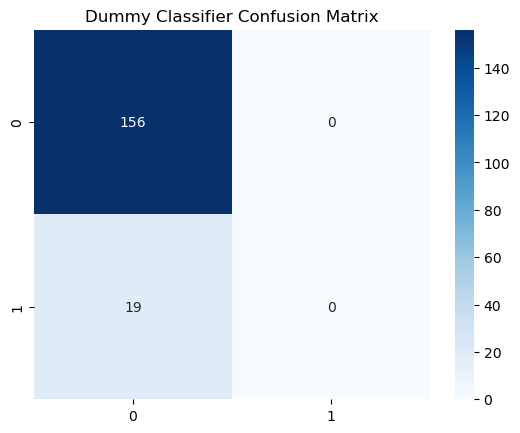

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-pa

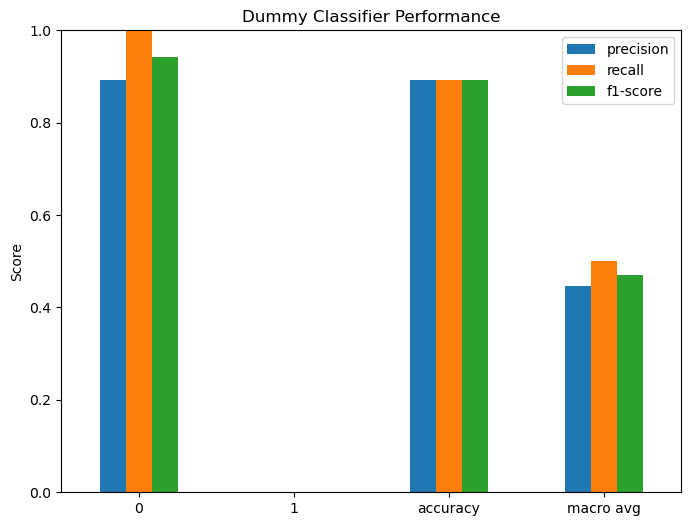

<Figure size 640x480 with 0 Axes>

In [ ]:
# Dummy classifier to have a baseline for our machine learning model. This will help us understand how well our model is performing compared to a simple baseline that always predicts the majority class.
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)
y_dummy_pred = dummy_clf.predict(X_test)


plt.title("Dummy Classifier Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_dummy_pred), annot=True, fmt="d", cmap="Blues")


#Saving the confusion matrix plot for the dummy classifier.
plt.savefig(result_path / "dummy_classifier_confusion_matrix.png")
plt.show()
# Since this is dummy classifier we are expecting to have 0 precision, recall and f1-score for the final exam class, and 1 for the ordinary term class, 
# as the dummy classifier will always predict the majority class, which is the ordinary term in our case. 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


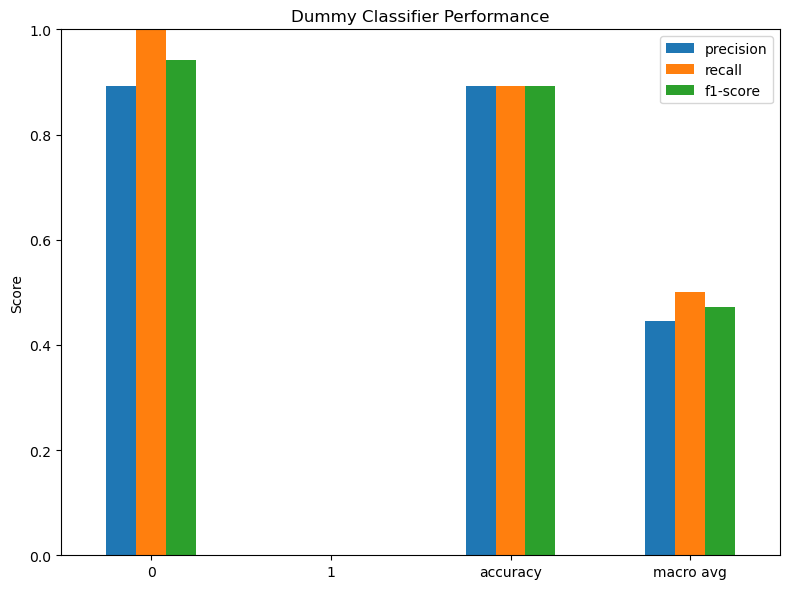

In [63]:
# Showing the scores of f1-score, precision and recall for the dummy in bar plot.
dummy_report = classification_report(y_test, y_dummy_pred, output_dict=True)
dummy_df = pd.DataFrame(dummy_report).transpose().iloc[:-1, :3]

ax = dummy_df.plot(kind="bar", figsize=(8, 6))

plt.title("Dummy Classifier Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()

# Saving the dummy classifier results in csv and png to the folder results.
dummy_df.to_csv(result_path / "dummy_classifier_report.csv")
plt.savefig(result_path / "dummy_classifier_performance.png", dpi=300, bbox_inches="tight")

plt.show()

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.47      0.62       156
           1       0.13      0.63      0.21        19

    accuracy                           0.49       175
   macro avg       0.52      0.55      0.41       175
weighted avg       0.83      0.49      0.57       175



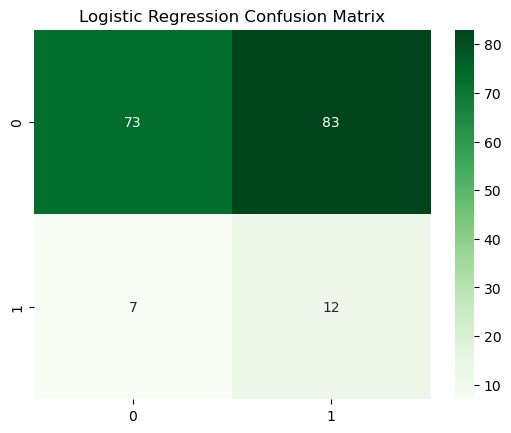

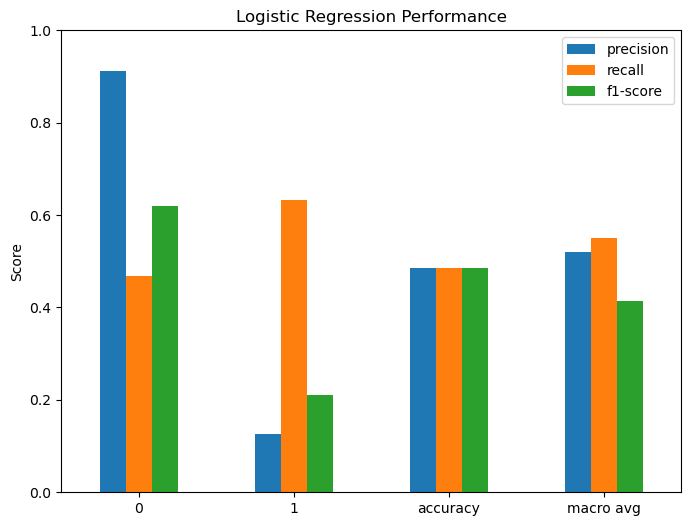

In [75]:
#---------------------LOGISTIC REGRESSION-----------------------#
# Logistic regression model to predict whether a day is in the final exam period or not based on the daily entertainment activity features.
#  I will use a pipeline to standardize the features and then fit the logistic regression model.


# Creating a pipeline that includes a standard scaler to standardize the features and a logistic regression model to predict the target variable.

# Max_iteration is to make sure model converges, as we have a small dataset and some features that could be correlated, 
# which could lead to convergence issues for the logistic regression model. By increasing the max_iter parameter,
#  we allow the model to have more iterations to find the optimal coefficients for the features, which can help improve the performance of the model.


log_reg_pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(class_weight="balanced", max_iter=1000)),])

# Implementing the pipeline to fit the logistic regression model on the training data.
log_reg_pipeline.fit(X_train, y_train)

# predicting the target variable on the test data using the fitted logistic regression model.
y_log_reg_pred = log_reg_pipeline.predict(X_test)
# Evaluating the performance of the logistic regression model by showing the classification report and confusion matrix.
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_log_reg_pred))


# Heat map for confusion matrix of logistic regression model.
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_log_reg_pred), annot=True, fmt="d", cmap="Greens")

# Saving the confusion matrix plot for the logistic regression model.
plt.savefig(result_path / "logistic_regression_confusion_matrix.png")

plt.show()



# bar plot for showing the macrof1 score, precision and recall scores for the logistic regression model.
log_reg_report = classification_report(y_test, y_log_reg_pred, output_dict=True)
log_reg_df = pd.DataFrame(log_reg_report).transpose().iloc[:-1, :3] 
log_reg_df.plot(kind="bar", figsize=(8, 6))
plt.title("Logistic Regression Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")

# Saving the logistic regression results in csv and png to the folder results.
log_reg_df.to_csv(result_path / "logistic_regression_report.csv")
plt.savefig(result_path / "logistic_regression_performance.png", dpi=300, bbox_inches="tight")

plt.show()


In [76]:
#---------------------------------------------- DECISION TREE CLASSIFIER----------------------------------------------#
# Decision tree classifier to predict whether a day is in the final exam period or not based on the daily entertainment activity features. 




# We can divide the train to have validation set as well to have hyperparameter tuning for the decision tree model
#

x_train_sub, x_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

max_depth_values = [2, 3, 4, 5, 6 , 7, 8, 9, 10]
best_f1_score = 0
best_max_depth = None

for max_depth in max_depth_values:
    model = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=max_depth)
    model.fit(x_train_sub, y_train_sub)
    y_val_pred = model.predict(x_val)
    report = classification_report(y_val, y_val_pred, output_dict=True)
    f1_score = report["macro avg"]["f1-score"]
    
    print(f"Max Depth: {max_depth}, F1 Score: {f1_score:.4f}")
    
    if f1_score > best_f1_score:
        best_f1_score = f1_score
        best_max_depth = max_depth


print(f"Best Max Depth: {best_max_depth}, Best F1 Score: {best_f1_score:.4f}")


Max Depth: 2, F1 Score: 0.3800
Max Depth: 3, F1 Score: 0.3549
Max Depth: 4, F1 Score: 0.3960
Max Depth: 5, F1 Score: 0.4276
Max Depth: 6, F1 Score: 0.4091
Max Depth: 7, F1 Score: 0.4299
Max Depth: 8, F1 Score: 0.4242
Max Depth: 9, F1 Score: 0.4204
Max Depth: 10, F1 Score: 0.4260
Best Max Depth: 7, Best F1 Score: 0.4299


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76       156
           1       0.16      0.58      0.26        19

    accuracy                           0.63       175
   macro avg       0.55      0.61      0.51       175
weighted avg       0.84      0.63      0.70       175



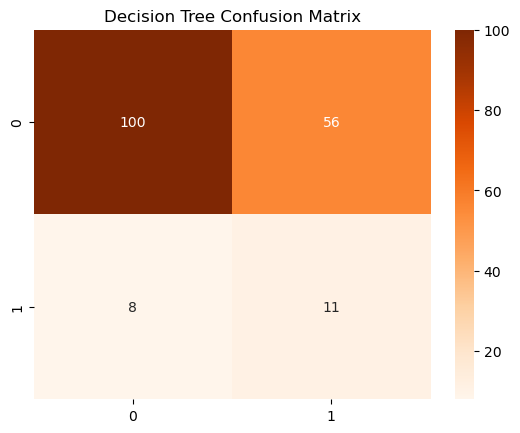

In [78]:
# Fitting the decision tree model with the best max_depth on the training data and evaluating it on the test data.
best_decision_tree = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=best_max_depth)
best_decision_tree.fit(X_train, y_train)
y_decision_tree_pred = best_decision_tree.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_decision_tree_pred))

# Heat map for confusion matrix of decision tree model.
plt.title("Decision Tree Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_decision_tree_pred), annot=True, fmt="d", cmap="Oranges")
plt.savefig(result_path / "decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# saving the plot 


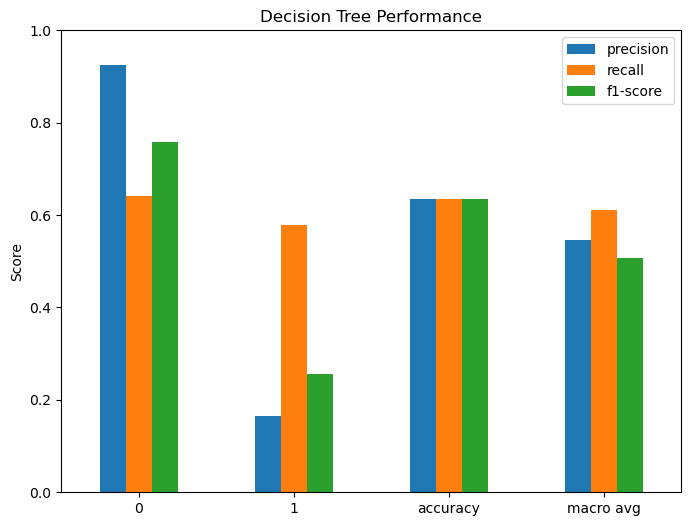

In [79]:
# Showing the scores of f1-score, precision and recall for the decision tree in bar plot.
decision_tree_report = classification_report(y_test, y_decision_tree_pred, output_dict=True)
decision_tree_df = pd.DataFrame(decision_tree_report).transpose().iloc[:-1, :3] 
decision_tree_df.plot(kind="bar", figsize=(8, 6))
plt.title("Decision Tree Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")


# saving the decision tree results in csv and png to the folder results.
decision_tree_df.to_csv(result_path / "decision_tree_report.csv")
plt.savefig(result_path / "decision_tree_performance.png", dpi=300, bbox_inches="tight")

plt.show()